In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import regionmask
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import matplotlib.cm as mpl_cm

In [2]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
        """Swaps longitude coordinates from range (0, 360) to (-180, 180)
        Args:
            dataset (xr.Dataset): xarray Dataset
        Returns:
            xr.Dataset: xarray Dataset with swapped longitude dimensions
        """
        lon_name = "lon"  # whatever name is in the data

        # Adjust lon values to make sure they are within (-180, 180)
        dataset["_longitude_adjusted"] = xr.where(
            dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
        dataset = (
            dataset.swap_dims({lon_name: "_longitude_adjusted"})
            .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
            .drop_vars(lon_name)
        )

        dataset = dataset.rename({"_longitude_adjusted": lon_name})
        return dataset


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [3]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, scenario, start, end, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ens = []

    for ens_num in range(1, 11):
        ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_{scenario}_{ens_num:02d}_{start}-{end}.nc"))

    da = xr.concat(ens, dim=xr.DataArray(np.arange(1, len(ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        da = land_filter(da)

    return da

In [4]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/OSDMA8_BC/"

# === Main loop ===
arise_o3 = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", 2050, 2069, land_mask=True)
ssp245_o3_early = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", 2020, 2039, land_mask=True)
ssp245_o3_late = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", 2050, 2069, land_mask=True)

Filtering ocean
Filtering ocean
Filtering ocean


/glade/derecho/scratch/awells/tmp/ipykernel_17542/1308795459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col_map = mpl_cm.get_cmap('Blues_r')


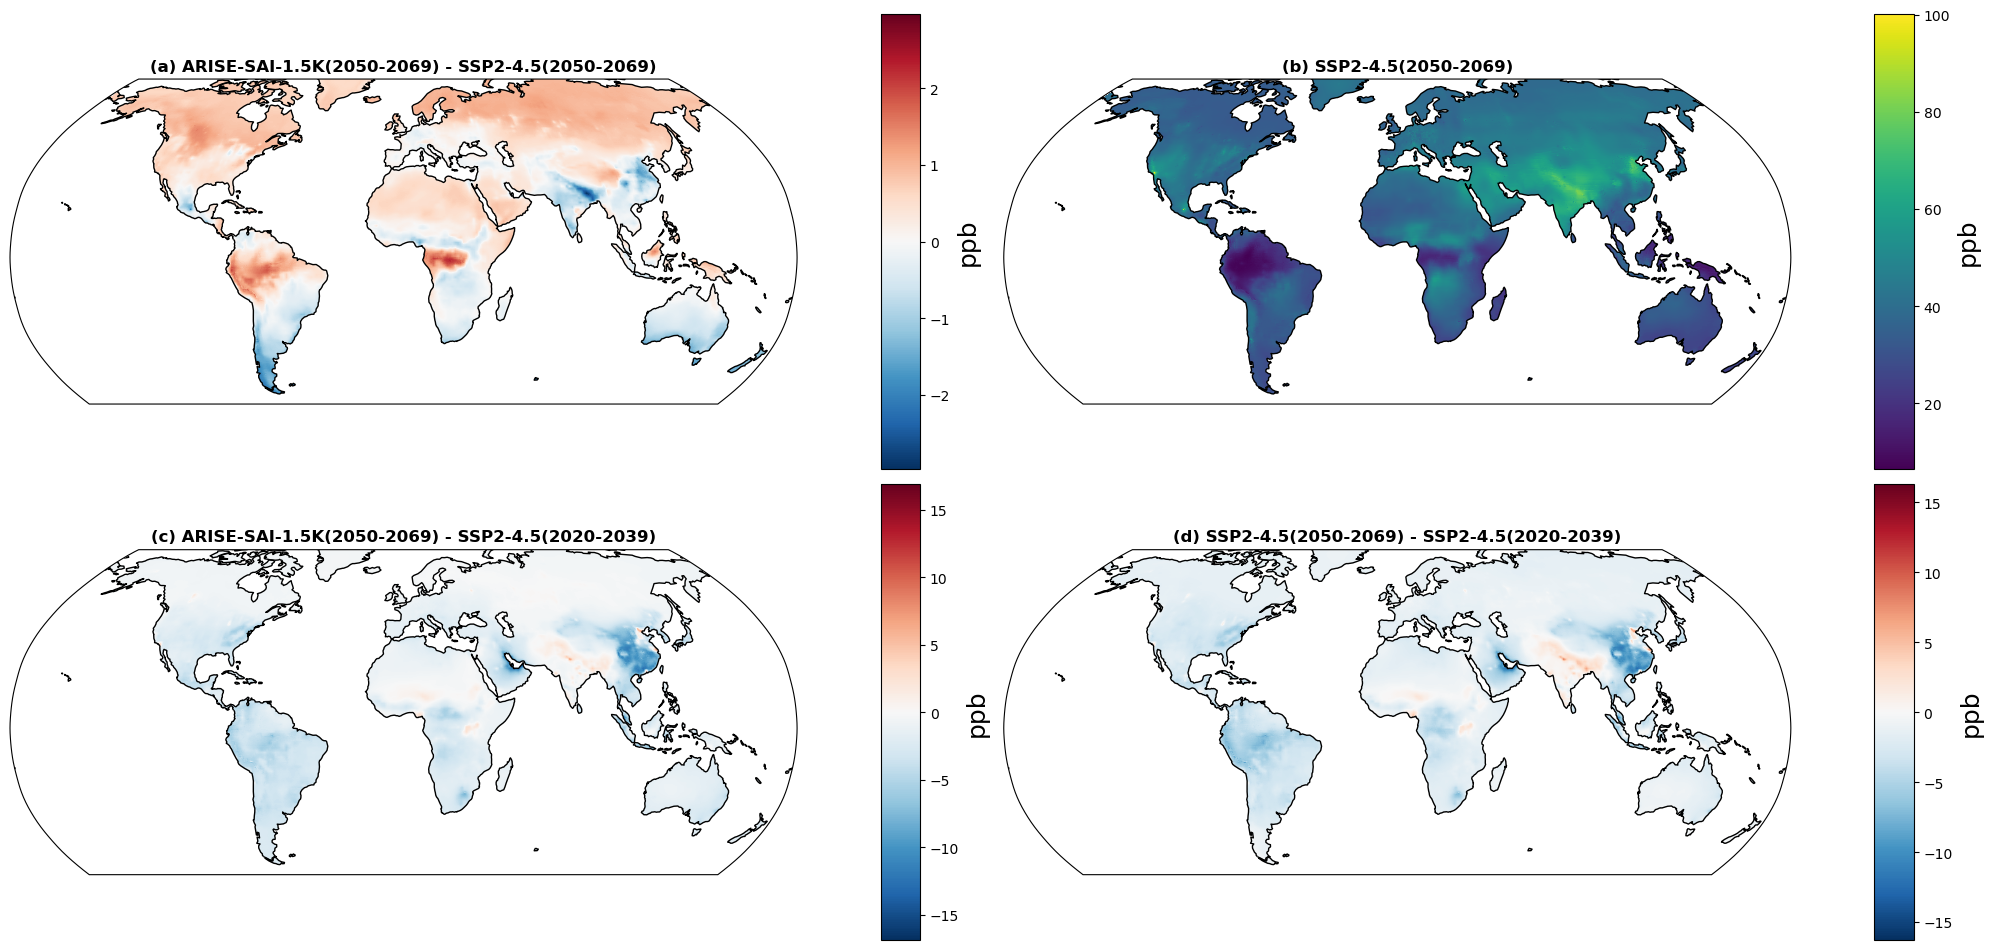

In [5]:
fig = plt.figure(figsize=autosize_figure(2, 2, xscale_factor=1.5))
gs = GridSpec(2, 4, width_ratios=[20, 1, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

arise = arise_o3.mean("ensemble")
ssp245_early = ssp245_o3_early.mean("ensemble")
ssp245_late = ssp245_o3_late.mean("ensemble")

col_map = mpl_cm.get_cmap('Blues_r')

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = (arise - ssp245_late).plot(transform=crs, add_colorbar=False, 
                         subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(a) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[0, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('ppb', fontsize=18)

# Second panel
ax = fig.add_subplot(gs[0, 2], projection=projection, frameon=True)
cb = ssp245_late.plot(transform=crs, add_colorbar=False,
                          subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(b) SSP2-4.5(2050-2069)', fontweight='bold')

# Second colorbar
cax = fig.add_subplot(gs[0, 3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('ppb', fontsize=18)

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = (arise - ssp245_early).plot(transform=crs, add_colorbar=False, 
                                    subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(c) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2020-2039)', fontweight='bold')

# Third colorbar
cax = fig.add_subplot(gs[1, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('ppb', fontsize=18)

# Fourth panel
ax = fig.add_subplot(gs[1, 2], projection=projection, frameon=True)
cb = (ssp245_late - ssp245_early).plot(transform=crs, add_colorbar=False,
                                    subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(d) SSP2-4.5(2050-2069) - SSP2-4.5(2020-2039)', fontweight='bold')

# Fourth colorbar
cax = fig.add_subplot(gs[1,3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('ppb', fontsize=18)

plt.tight_layout()


/glade/derecho/scratch/awells/tmp/ipykernel_17542/3334117823.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col_map = mpl_cm.get_cmap('Blues_r')


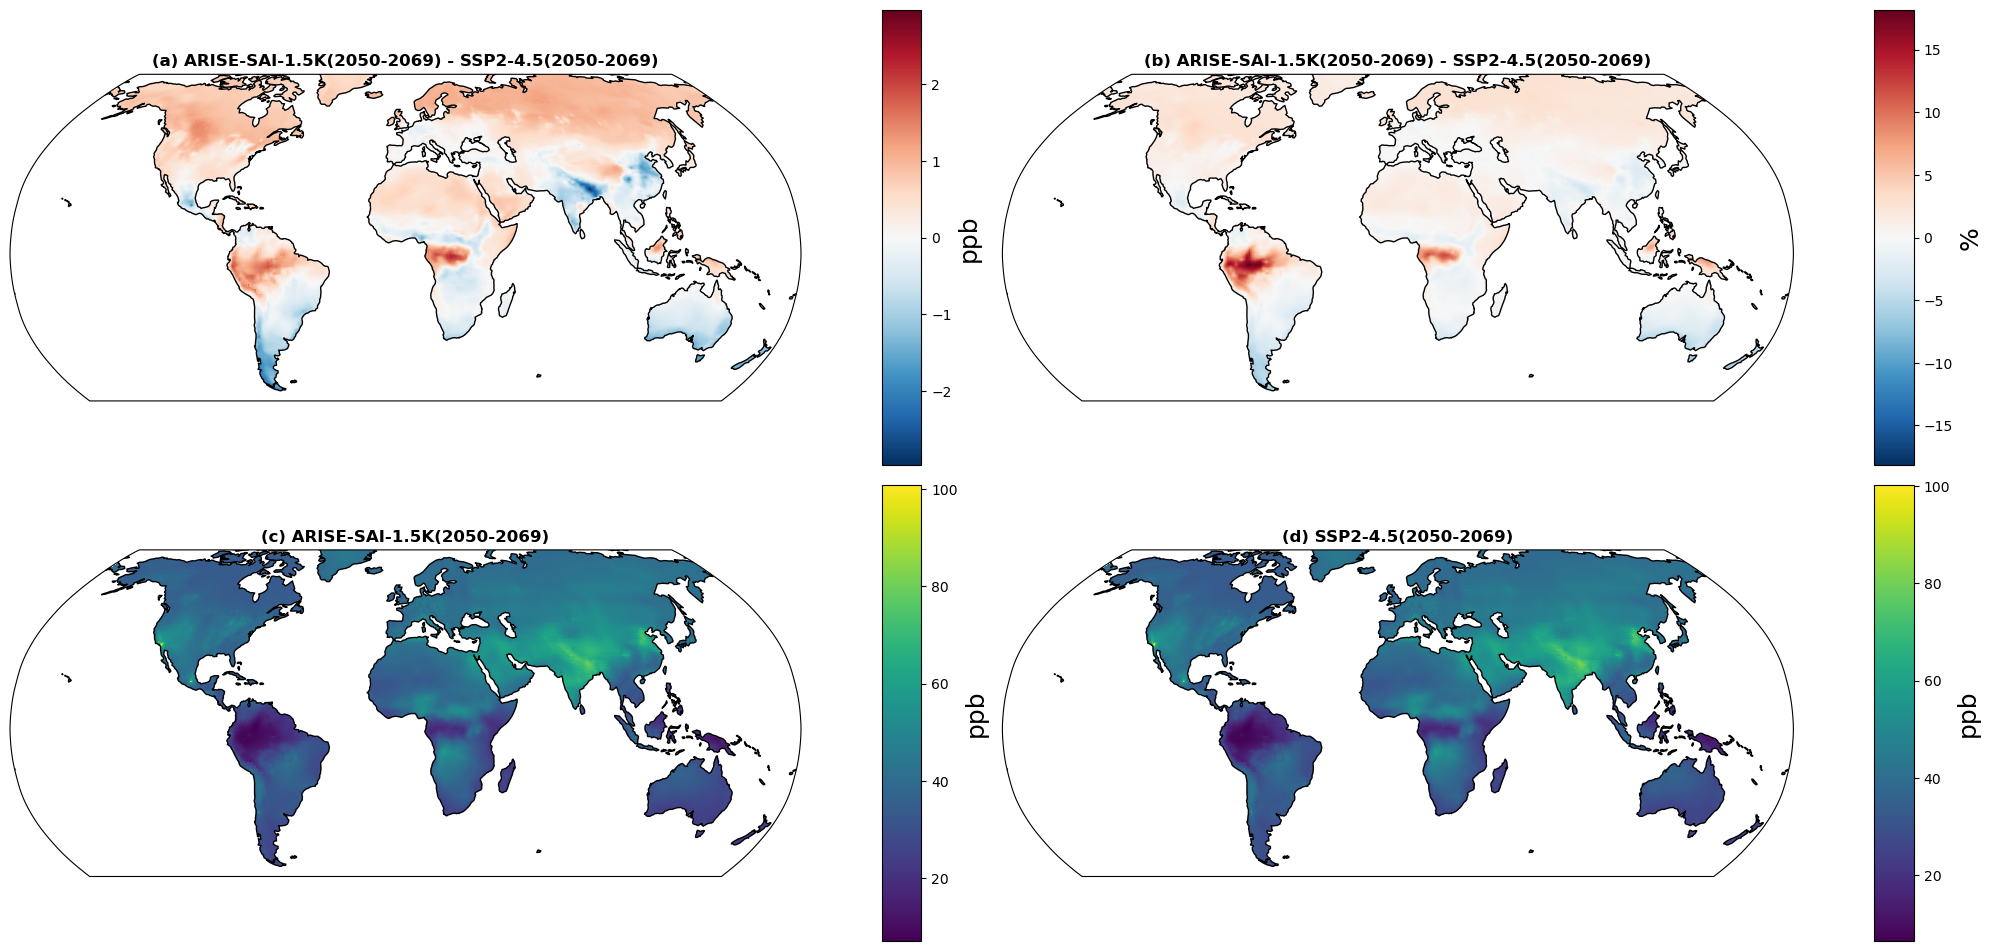

In [8]:
fig = plt.figure(figsize=autosize_figure(2, 2, xscale_factor=1.5))
gs = GridSpec(2, 4, width_ratios=[20, 1, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

arise = arise_o3.mean("ensemble")
ssp245_early = ssp245_o3_early.mean("ensemble")
ssp245_late = ssp245_o3_late.mean("ensemble")

col_map = mpl_cm.get_cmap('Blues_r')

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = (arise - ssp245_late).plot(transform=crs, add_colorbar=False, 
                         subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(a) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[0, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('ppb', fontsize=18)

# Second panel
ax = fig.add_subplot(gs[0, 2], projection=projection, frameon=True)
cb = (((arise - ssp245_late)/ssp245_late)*100).plot(transform=crs, add_colorbar=False,
                          subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(b) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)', fontweight='bold')

# Second colorbar
cax = fig.add_subplot(gs[0, 3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('%', fontsize=18)

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = arise.plot(transform=crs, add_colorbar=False, 
                                    subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(c) ARISE-SAI-1.5K(2050-2069)', fontweight='bold')

# Third colorbar
cax = fig.add_subplot(gs[1, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('ppb', fontsize=18)

# Fourth panel
ax = fig.add_subplot(gs[1, 2], projection=projection, frameon=True)
cb = ssp245_late.plot(transform=crs, add_colorbar=False,
                                    subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(d) SSP2-4.5(2050-2069)', fontweight='bold')

# Fourth colorbar
cax = fig.add_subplot(gs[1,3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('ppb', fontsize=18)

plt.tight_layout()
